# Personal Finance Expense Analysis
## Import Libraries

In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
sns.set_theme(style="whitegrid")

## Load Cleaned Dataset

In [5]:
df=pd.read_csv('Expenses_Final.csv')
df.head()

,date_time,category,account,amount,tags,Month,Day_of_Week,Is_Weekend
0,2025-11-30,Health,acct_1,114.0,tag_1,November,Sunday,True
1,2025-11-29,Food,acct_1,5.0,tag_1,November,Saturday,True
2,2025-11-27,Public transport,acct_2,1.0,tag_1,November,Thursday,False
3,2025-11-27,Cafe,acct_1,10.0,tag_1,November,Thursday,False
4,2025-11-26,Cafe,acct_3,2.0,tag_1,November,Wednesday,False


## Dataset Overview

In [6]:
df.shape

(793, 8)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 793 entries, 0 to 792
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date_time    793 non-null    object 
 1   category     793 non-null    object 
 2   account      793 non-null    object 
 3   amount       793 non-null    float64
 4   tags         793 non-null    object 
 5   Month        793 non-null    object 
 6   Day_of_Week  793 non-null    object 
 7   Is_Weekend   793 non-null    bool   
dtypes: bool(1), float64(1), object(6)
memory usage: 44.3+ KB


In [8]:
df.describe()

,amount
count,793.000000
mean,18.528373
std,84.881525
min,0.000000
25%,1.000000
50%,5.000000
75%,12.000000
max,1172.000000


## Univariate Analysis

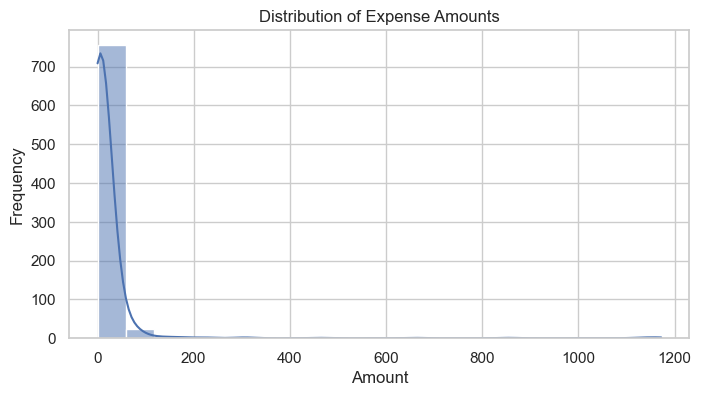

In [11]:
# 1. Spending distribution
# How are expense amounts distributed?

plt.figure(figsize=(8,4))
sns.histplot(df['amount'], bins=20, kde=True)
plt.title('Distribution of Expense Amounts')
plt.xlabel('Amount')
plt.ylabel('Frequency')
plt.show()

Most expense amounts are small.
Only a few transactions have very large expense amounts.
The distribution is right-skewed (positively skewed)

In [12]:
# 2.Category-wise Spending
#Which category contributes the highest total expenses?

category_spend=df.groupby('category')['amount'].sum().sort_values(ascending=False)
category_spend

category
Loan given           2809.0
Other                2699.0
Food                 1528.0
Cafe                 1413.0
Gifts                1277.0
Bought for myself    1273.0
Leisure               945.0
Health                804.0
Taxi                  770.0
Clothes               548.0
Public transport      368.0
Job                   133.0
University             81.0
Fines                  45.0
Name: amount, dtype: float64

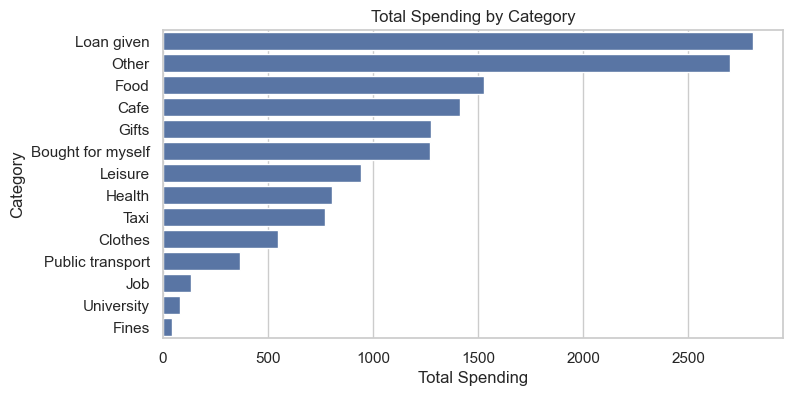

In [13]:
plt.figure(figsize=(8,4))
sns.barplot(x=category_spend.values, y=category_spend.index)
plt.title('Total Spending by Category')
plt.xlabel("Total Spending")
plt.ylabel("Category")
plt.show()

Loan given is the highest expense category.
Other is the second highest spending category.
Food is the highest regular day-to-day expense.

In [18]:
# 3. Monthly Spending Trend

monthly=df.groupby('Month')['amount'].sum()
monthly

month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

monthly = monthly.reindex(month_order).dropna()

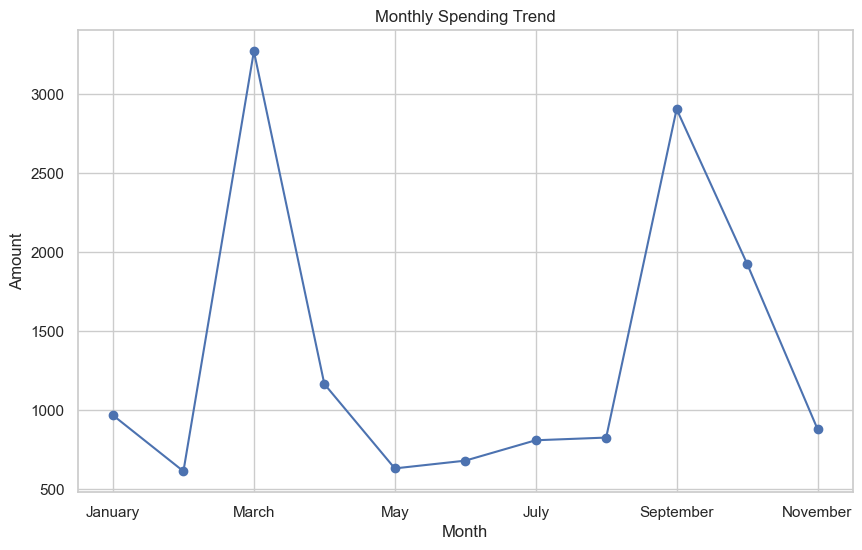

In [20]:
plt.figure(figsize=(10,6))
monthly.plot(kind='line', marker='o')
plt.title('Monthly Spending Trend')
plt.xlabel('Month')
plt.ylabel('Amount')
plt.show()

Spending reached its highest level in March.
A second spending peak occurred in September.
February and May had the lowest spending.

In [25]:
# 4.Weekday vs Weekend
#total spending on weekdays vs weekends
total_spending = df.groupby('Is_Weekend')['amount'].sum()
total_spending

Is_Weekend
False    12166.0
True      2527.0
Name: amount, dtype: float64

In [23]:
# avg spending on weekdays vs weekends
average_spending = df.groupby("Is_Weekend")["amount"].mean().round(2)
average_spending

Is_Weekend
False    19.07
True     16.30
Name: amount, dtype: float64

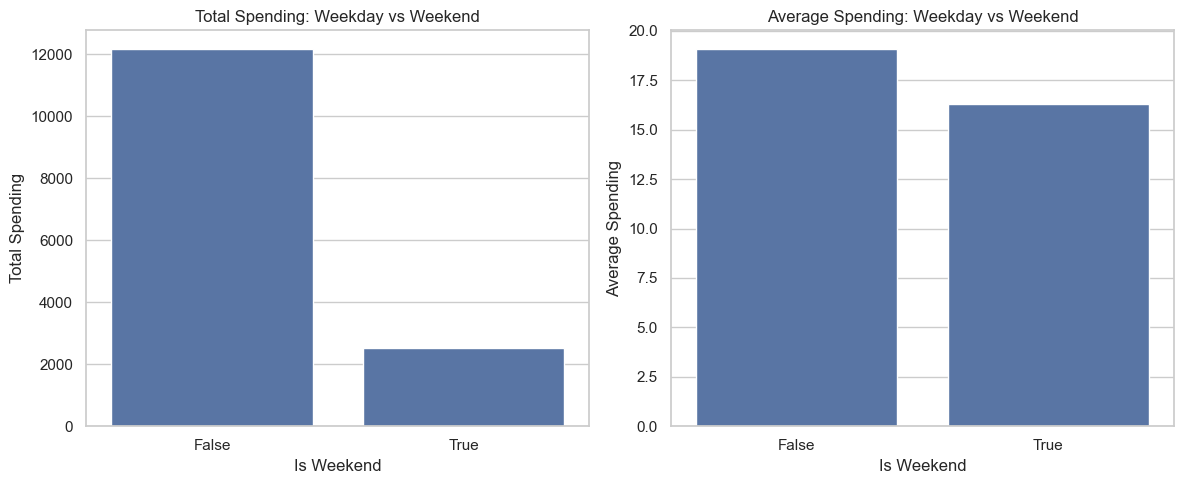

In [26]:

plt.figure(figsize=(12,5))

# First Chart
plt.subplot(1,2,1)
sns.barplot(x=total_spending.index, y=total_spending.values)
plt.title("Total Spending: Weekday vs Weekend")
plt.xlabel("Is Weekend")
plt.ylabel("Total Spending")

# Second Chart
plt.subplot(1,2,2)
sns.barplot(x=average_spending.index, y=average_spending.values)
plt.title("Average Spending: Weekday vs Weekend")
plt.xlabel("Is Weekend")
plt.ylabel("Average Spending")

plt.tight_layout()
plt.show()

### Total Spending
Total spending is much higher on weekdays than on weekends.
Most expenses occur during weekdays.
### Average Spending
The average amount spent per transaction is also slightly higher on weekdays.
Weekend transactions tend to be smaller on average.

In [ ]:
# 5.Spending by Day of Week
day = df.groupby("Day_of_Week")["amount"].sum()
day

Day_of_Week
Friday       1395.0
Monday       2150.0
Saturday     1284.0
Sunday       1243.0
Thursday     2012.0
Tuesday      1932.0
Wednesday    4677.0
Name: amount, dtype: float64

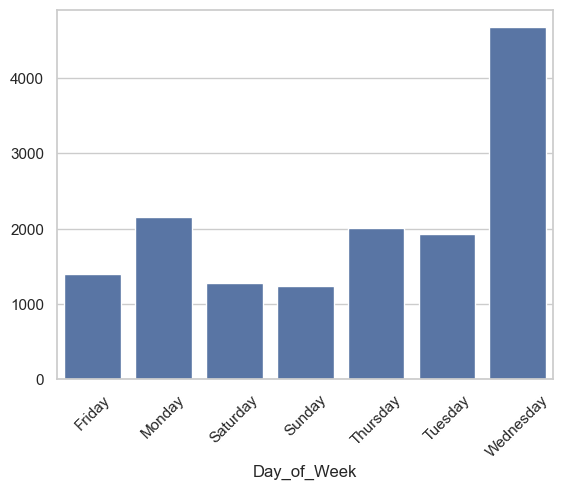

In [28]:
sns.barplot(
    x=day.index,
    y=day.values
)

plt.xticks(rotation=45)

plt.show()

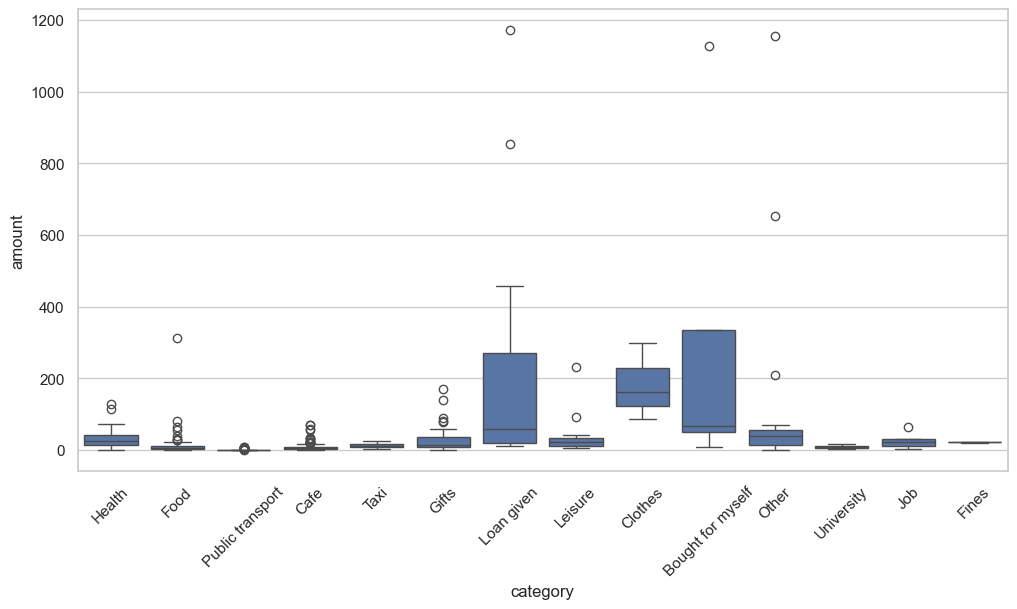

In [29]:
# 6.Box Plot
# Which categories have the most variable spending?
plt.figure(figsize=(12,6))

sns.boxplot(
    x="category",
    y="amount",
    data=df
)

plt.xticks(rotation=45)

plt.show()

In [38]:
# 6. Heatmap
# Which months and weekdays have the highest spending?

month_order = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

day_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]
pivot = df.pivot_table(
    values="amount",
    index="Day_of_Week",
    columns="Month",
    aggfunc="sum"
)
pivot = pivot.reindex(index=day_order, columns=month_order)

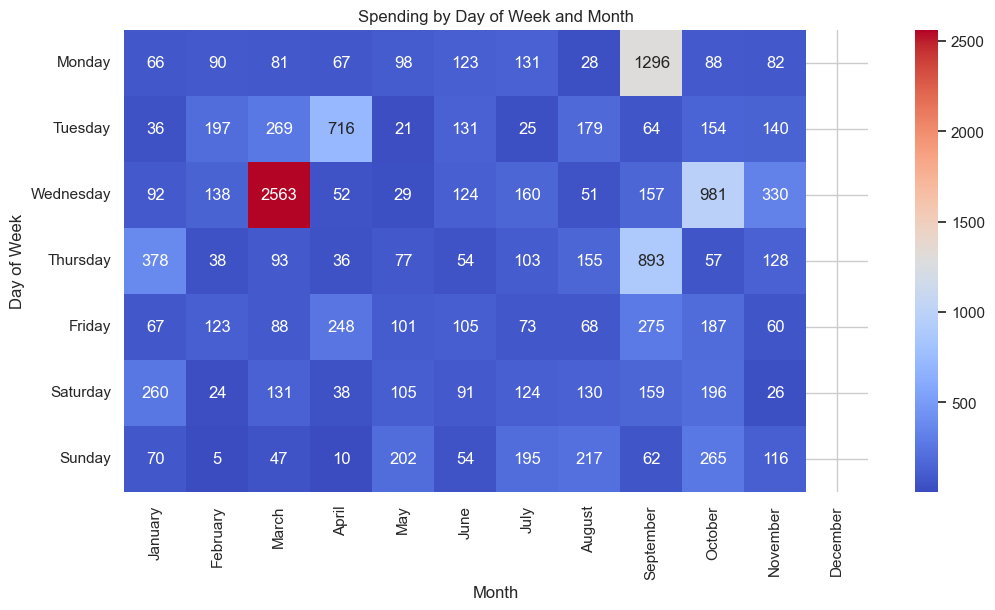

In [40]:
plt.figure(figsize=(12,6))

sns.heatmap(
    pivot,
    annot=True,
    fmt=".0f",
    cmap="coolwarm"
)

plt.title("Spending by Day of Week and Month")
plt.xlabel("Month")
plt.ylabel("Day of Week")

plt.show()

Wednesday in March has the highest spending, making it the peak spending period.
Spending is generally higher in March and September than in most other months.

In [33]:
df.nlargest(10,"amount")

,date_time,category,account,amount,tags,Month,Day_of_Week,Is_Weekend
680,2025-03-05,Loan given,acct_1,1172.0,tag_1,March,Wednesday,False
681,2025-03-05,Other,acct_1,1156.0,tag_1,March,Wednesday,False
161,2025-09-29,Bought for myself,acct_1,1129.0,tag_1,September,Monday,False
106,2025-10-15,Loan given,acct_1,854.0,tag_1,October,Wednesday,False
539,2025-04-29,Other,acct_1,654.0,tag_1,April,Tuesday,False
211,2025-09-11,Loan given,acct_1,457.0,tag_1,September,Thursday,False
176,2025-09-25,Food,acct_1,313.0,tag_1,September,Thursday,False
48,2025-11-05,Clothes,acct_1,299.0,tag_1,November,Wednesday,False
173,2025-09-26,Leisure,acct_1,232.0,tag_1,September,Friday,False
760,2025-01-23,Other,acct_1,210.0,tag_1,January,Thursday,False


# Statistical Analysis

## 1. Hypothesis Testing (t-test)

In [ ]:
# Do people spend significantly more on weekdays than weekends? OR Is there a significant difference between weekday and weekend spending?

from scipy import stats

weekday = df[df["Is_Weekend"] == False]["amount"]
weekend = df[df["Is_Weekend"] == True]["amount"]

t_stat, p_value = stats.ttest_ind(weekday, weekend)

print("T-statistic:", round(t_stat, 2))
print("P-value:", round(p_value, 4))

T-statistic: 0.36
P-value: 0.7162


In [43]:
if p_value < 0.05:
    print("There is a significant difference between weekday and weekend spending.")
else:
    print("There is no significant difference between weekday and weekend spending.")

There is no significant difference between weekday and weekend spending.


## Check Distribution (Shapiro-Wilk Test)


In [44]:
# Is the spending approximately normally distributed?
from scipy.stats import shapiro

stat, p = shapiro(df["amount"])

print("Statistic:", round(stat, 4))
print("P-value:", round(p, 4))

Statistic: 0.1634
P-value: 0.0


In [45]:
if p > 0.05:
    print("The data is approximately normally distributed.")
else:
    print("The data is not normally distributed.")

The data is not normally distributed.


## 95% Confidence Interval

In [46]:
# What is the estimated range of the average spending?
from scipy import stats

mean = df["amount"].mean()

ci = stats.t.interval(
    confidence=0.95,
    df=len(df)-1,
    loc=mean,
    scale=stats.sem(df["amount"])
)

print("Average Spending:", round(mean,2))
print("95% Confidence Interval:", ci)

Average Spending: 18.53
95% Confidence Interval: (np.float64(12.611546348215011), np.float64(24.445200183941356))
